# 03 - Full-Waveform Inversion (FWI)

This notebook is the third in a series of tutorial highlighting various aspects of seismic inversion based on Devito operators. In this second example we aim to highlight the core ideas behind seismic inversion, where we create an image of the subsurface from field recorded data. This tutorial follows on the modelling tutorial and will reuse the modelling and velocity model.

## Inversion requirement

Seismic inversion relies on two known parameters:

- **Field data** - or also called **recorded data**. This is a shot record corresponding to the true velocity model. In practice this data is acquired as described in the first tutorial. In order to simplify this tutorial we will fake field data by modelling it with the true velocity model.

- **Initial velocity model**. This is a velocity model that has been obtained by processing the field data. This model is a rough and very smooth estimate of the velocity as an initial estimate for the inversion. This is a necessary requirement for any optimization (method).

## Inversion computational setup

In this tutorial, we will introduce the gradient operator. This operator corresponds to the imaging condition introduced in the previous tutorial with some minor modifications that are defined by the objective function (also referred to in the tutorial series as the *functional*, *f*) and its gradient, *g*. We will define these two terms in the tutorial too.

## Notes on the operators

As we have already described the creation of a forward modelling operator, we will only call a wrapper function here. This wrapper already contains all the necessary operators for seismic modeling, imaging and inversion. Operators introduced for the first time in this tutorial will be properly described.

In [1]:
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")

In [2]:
import numpy as np
%matplotlib inline

from devito import configuration
configuration['log-level'] = 'WARNING'
configuration["platform"] = "nvidiaX"
configuration["language"] = "openmp"
configuration["compiler"] = "nvc"


## Computational considerations

As we will see, FWI is computationally extremely demanding, even more than RTM. To keep this tutorial as lightwight as possible we therefore again use a very small demonstration model. We also define here a few parameters for the final example runs that can be changed to modify the overall runtime of the tutorial.

In [3]:
nshots = 24  # Number of shots to create gradient from
nreceivers = 1  # Number of receiver locations per shot 
fwi_iterations = 5  # Number of outer FWI iterations

# True and smooth velocity models

We will use a very simple model domain, consisting of a circle within a 2D domain. We will again use the "true" model to generate our synthetic shot data and use a "smooth" model as our initial guess. In this case the smooth model is very smooth indeed - it is simply a constant background velocity without any features.

In [4]:
#NBVAL_IGNORE_OUTPUT
from examples.seismic import demo_model, plot_velocity, plot_perturbation, SeismicModel
from devito import gaussian_smooth

# Define true and initial model
shape = (500, 1000)  # Number of grid point (nx, nz)
spacing = (0.05, 0.05)  # Grid spacing in m. The domain size is now 1km by 1km
origin = (0., 0.)  # Need origin to define relative source and receiver locations

vp = np.ones(shape) * 2.5
vp[:, :400] = 1.5
vp[:, 600:] = 1.5

model = SeismicModel(
    space_order=4,
    vp=vp,
    origin=origin,
    shape=shape,
    dtype=np.float32,
    spacing=spacing,
    nbl=300,
    fs=False,
    # b=np.ones_like(vp),
    density=False,
    bcs="damp",
)

model0 = SeismicModel(
    space_order=4,
    vp=vp,
    origin=origin,
    shape=shape,
    dtype=np.float32,
    spacing=spacing,
    nbl=300,
    fs=False,
    # b=np.ones_like(vp),
    density=False,
    bcs="damp",
)

gaussian_smooth(model0.vp, sigma=10)

vp(x, y)

In [5]:
model.fs

False

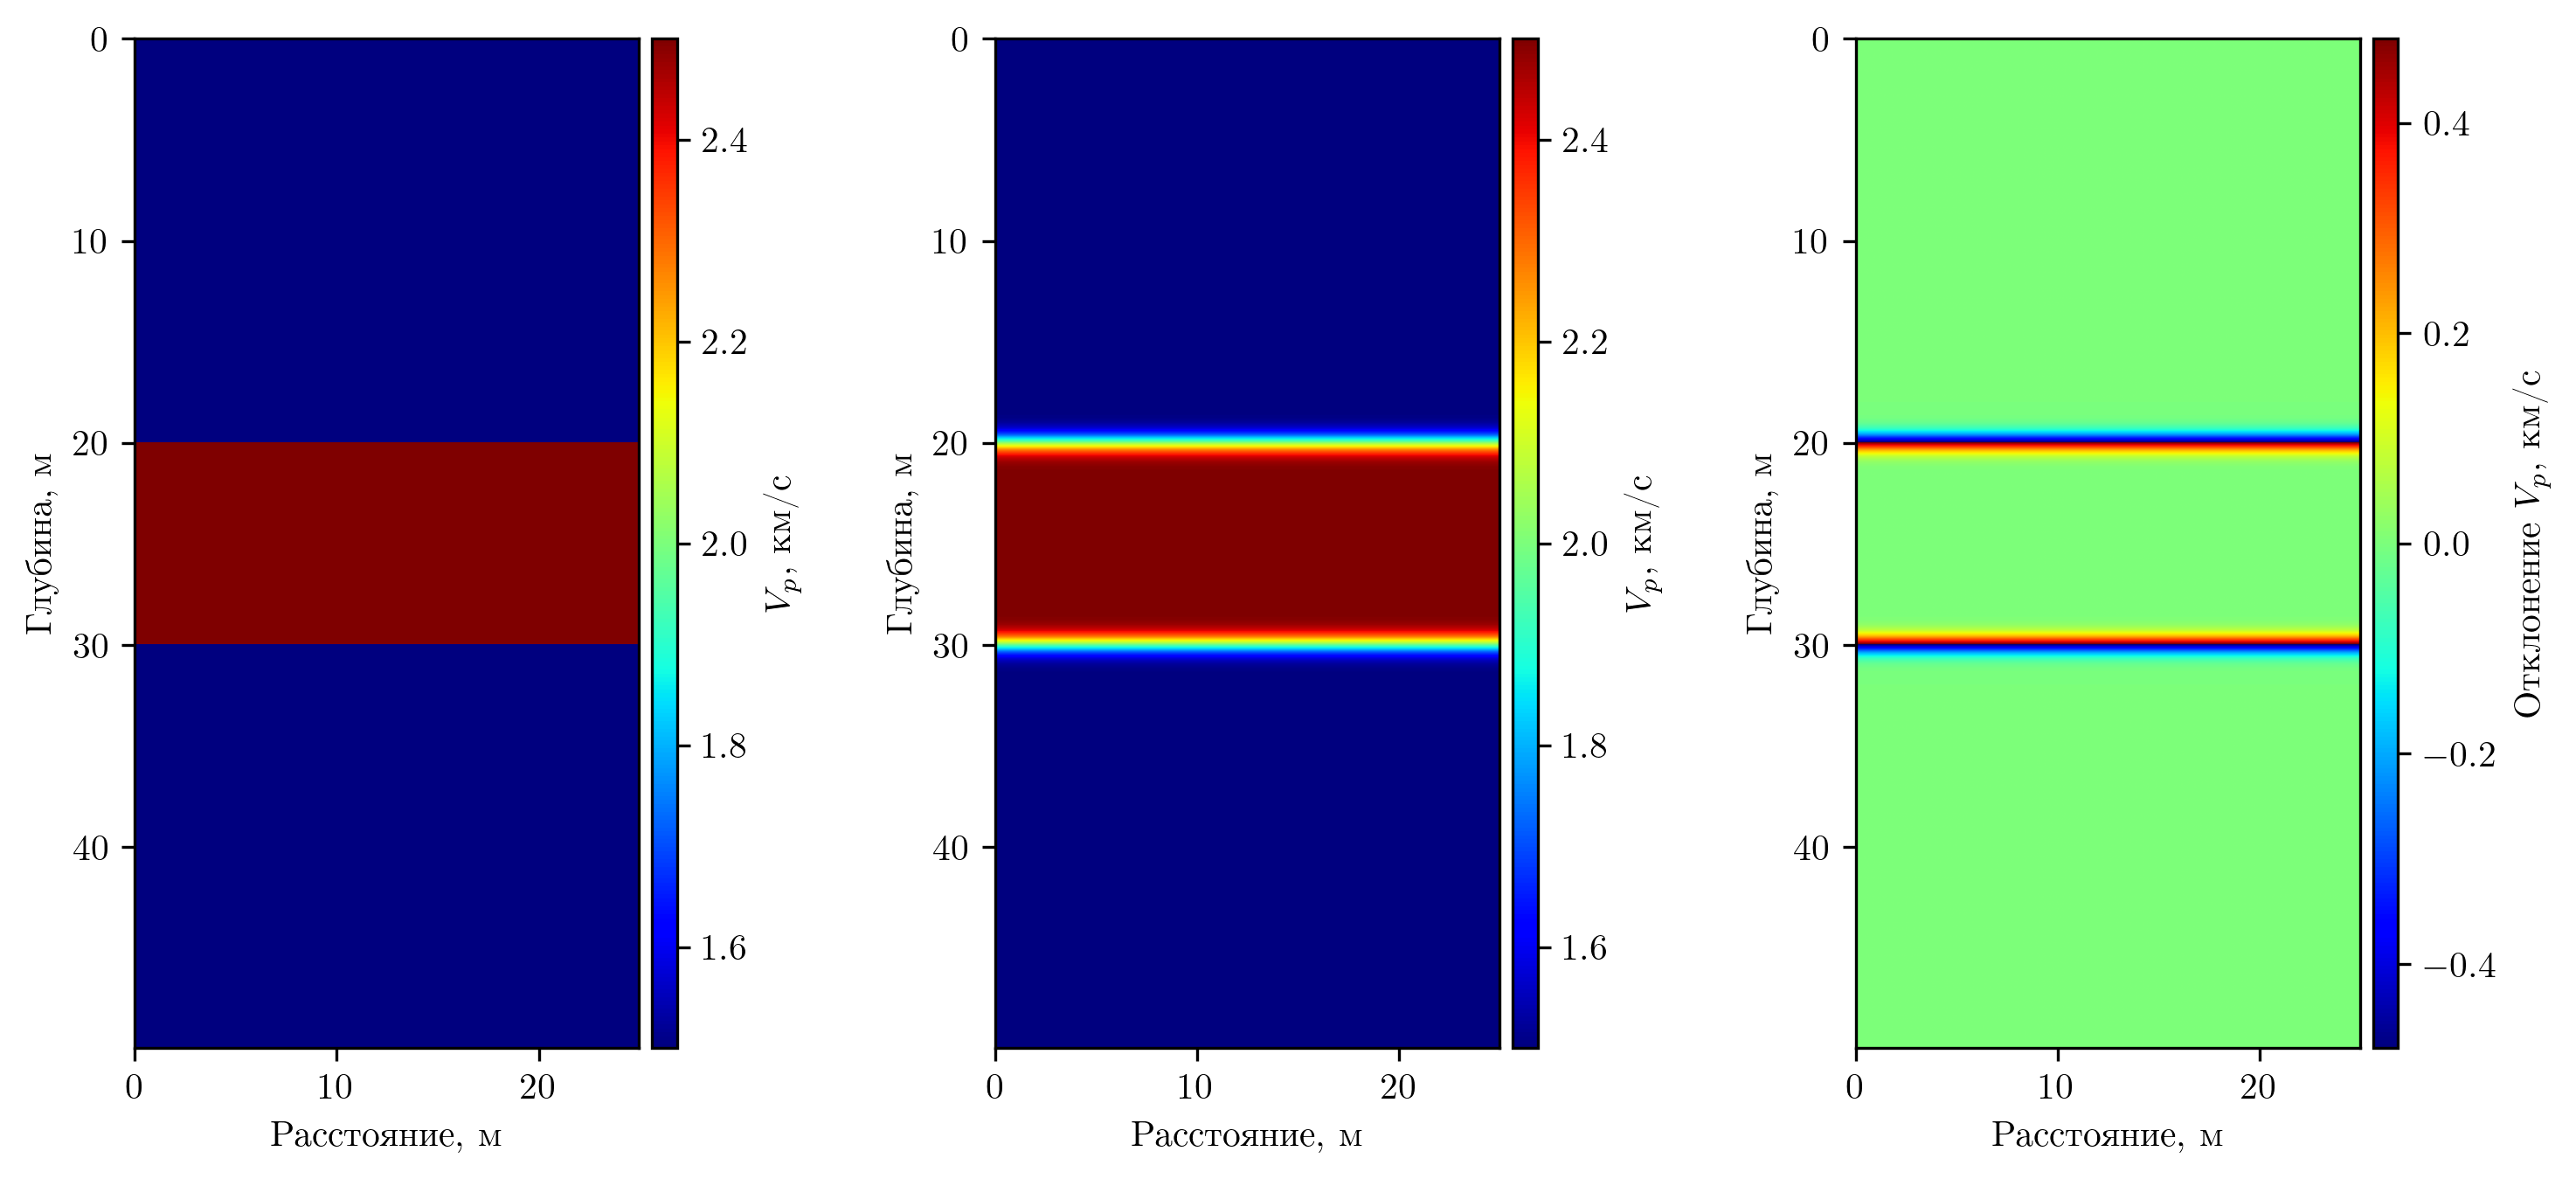

In [6]:
fig, axs = plt.subplots(1, 3, dpi=300, figsize=(12, 5))
plot_velocity(model, ax=axs[0])
plot_velocity(model0, ax=axs[1])
plot_perturbation(model, model0, ax=axs[2])
plt.savefig("../../../Wavepath/Pic 0.png")
plt.show()

## Acquisition geometry

In this tutorial, we will use the easiest case for inversion, namely a transmission experiment. The sources are located on one side of the model and the receivers on the other side. This allows to record most of the information necessary for inversion, as reflections usually lead to poor inversion results.

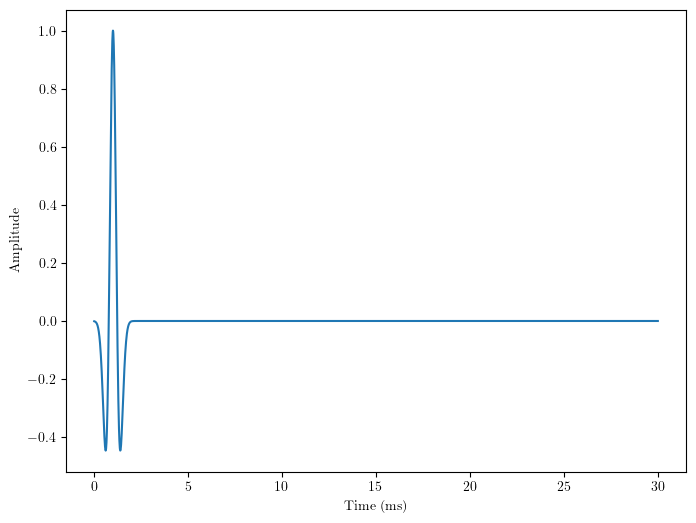

In [7]:
#NBVAL_IGNORE_OUTPUT
# Define acquisition geometry: source
from examples.seismic import AcquisitionGeometry

t0 = 0.
tn = 30. 
f0 = 1.0
# First, position source centrally in all dimensions, then set depth
src_coordinates = np.empty((1, 2))
# src_coordinates[0, :] = np.array(model.domain_size) * .5
src_coordinates[0, :] = np.array(model.domain_size) * .2
src_coordinates[0, 0] = 2.

# Define acquisition geometry: receivers

# Initialize receivers for synthetic and imaging data
rec_coordinates = np.empty((nreceivers, 2))
rec_coordinates[:, 1] = model.domain_size[1] * .2
rec_coordinates[:, 0] = 23.

# Geometry

geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')
# We can plot the time signature to see the wavelet
geometry.src.show()

In [8]:
from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [9]:
import numpy as np
from scipy.fft import fft, ifft, fftshift, ifftshift, rfft, irfft
from scipy.signal import hilbert

def minimal_phase_wavelet(wav_data):
    """
    Compute the minimal phase analogue of a wavelet.
    
    Parameters:
    - wav_data: Wavelet time-series data (1D array)
    - dt: Time step (sampling interval in seconds)
    
    Returns:
    - minimal_phase_wave: Minimal phase version of the wavelet
    """
    spec = fft(wav_data)
    arg_s = np.angle(spec)
    z_sup = hilbert(np.log(np.abs(spec)))
    arg_s_m = np.imag(z_sup)
    spec_s_m = abs(spec) * np.exp(-1j * arg_s_m)
    s_m = ifft(spec_s_m).real
    
    return s_m

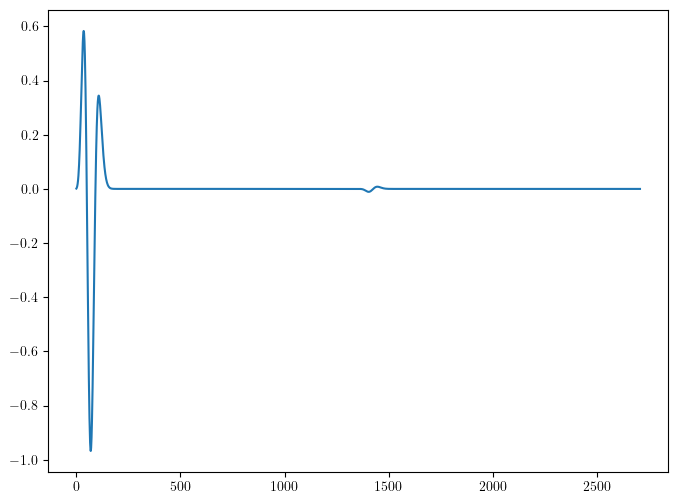

In [10]:
np.random.seed(42)
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')

wav_min = minimal_phase_wavelet(np.array(geometry.src.data).ravel() + np.random.normal(scale=0.0001))
# wav_min, _ = left_taper_tukey(wav_min[::-1], alpha=0.99)
# wav_min[50:] *= (np.arange(wav_min[50:].size, dtype=float)+1)**(-2)
plt.plot(wav_min)
plt.show()
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type=None, wav_data=-wav_min)
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')

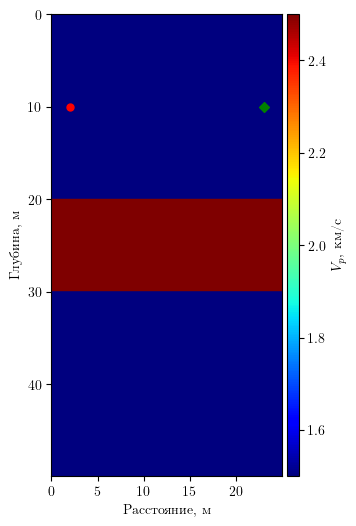

In [11]:
#NBVAL_IGNORE_OUTPUT
# Plot acquisition geometry
plot_velocity(model, source=geometry.src_positions,
              receiver=geometry.rec_positions[:, :])

## True and smooth data

We can generate shot records for the true and smoothed initial velocity models, since the difference between them will again form the basis of our imaging procedure.

In [12]:
# Compute synthetic data with forward operator 
from examples.seismic.acoustic import AcousticWaveSolver

solver = AcousticWaveSolver(model, geometry, space_order=4)
true_d, _, _ = solver.forward(vp=model.vp)
smooth_d, _, _ = solver.forward(vp=model0.vp)

In [13]:
# # Compute initial data with forward operator 
# smooth_d, _, _ = solver.forward(vp=model0.vp)

In [15]:
#NBVAL_IGNORE_OUTPUT
from examples.seismic import plot_shotrecord
from matplotlib import pyplot as plt
# ax = plot_shotrecord(true_d.data.T, model, t0, tn)
# plt.show()
# ax = plot_shotrecord(smooth_d.data.T, model, t0, tn)
# plt.show()
# ax = plot_shotrecord(smooth_d.data.T - true_d.data.T, model, t0, tn)
# plt.show()

In [16]:
geometry.time_axis.time_values.size

2707

In [17]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator


In [18]:
geometry = AcquisitionGeometry(
    model0, rec_coordinates, src_coordinates,
    t0, tn, f0=f0, src_type='Ricker'
)
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type=None, wav_data=wav_min)


## FWI gradient operator

To compute a single gradient $\nabla\Phi_s(\mathbf{m})$ in our optimization workflow we again use `solver.forward` to compute the entire forward wavefield $\mathbf{u}$ and a similar pre-defined gradient operator to compute the adjoint wavefield `v`. The gradient operator provided by our `solver` utility also computes the correlation between the wavefields, allowing us to encode a similar procedure to the previous imaging tutorial as our gradient calculation:

- Simulate the forward wavefield with the background velocity model to get the synthetic data and save the full wavefield $\mathbf{u}$
- Compute the data residual
- Back-propagate the data residual and compute on the fly the gradient contribution at each time step. 

This procedure is applied to multiple source positions and summed to obtain a gradient image of the subsurface. We again prepare the source locations for each shot and visualize them, before defining a single gradient computation over a number of shots as a single function.

In [19]:
# Create FWI gradient kernel 
from devito import Function, TimeFunction, norm
from examples.seismic import Receiver

u0s = []
vs = []
slices = (slice(None, None), slice(model.nbl//5-10, -model.nbl//5+10), slice(model.nbl//5-10, -model.nbl//5+10))

for s_pos, r_pos in zip([0.2, 0.2, 0.5, 0.2], [0.2, 0.5, 0.5, 0.8]):
    src_coordinates[0, :] = np.array(model.domain_size) * s_pos
    src_coordinates[0, 0] = 2.

    # Define acquisition geometry: receivers

    # Initialize receivers for synthetic and imaging data
    rec_coordinates = np.empty((nreceivers, 2))
    rec_coordinates[:, 1] = model.domain_size[1] * r_pos
    rec_coordinates[:, 0] = 23.
    geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')
    d_syn = Receiver(name='d_syn', grid=model.grid,
                        time_range=geometry.time_axis, 
                        coordinates=geometry.rec_positions)
    _, _, _ = solver.forward(vp=model0.vp, rec=d_syn)
    _, u0, _ = solver.forward(vp=model.vp, save=True, nsnaps=1000, space_subsample=(5, 5))
    _, v,  _ = solver.adjoint(rec=d_syn, vp=model.vp,  save=True, nsnaps=1000, space_subsample=(5, 5))
    u0s.append(np.array(u0.data)[slices])
    vs.append(np.array(v.data)[slices])

No source type defined, returning uninitialized (zero) source
No source type defined, returning uninitialized (zero) source
No source type defined, returning uninitialized (zero) source
No source type defined, returning uninitialized (zero) source
No source type defined, returning uninitialized (zero) source


In [20]:
import torch

u0_batch = torch.from_numpy(np.array(u0s))
v_batch = torch.from_numpy(np.array(vs))

In [21]:
def calc_grad_batch(u0_batch, v_batch, dt=1.0):
    """Compute gradient for batch using torch"""
    u0_padded = torch.nn.functional.pad(
        u0_batch, (0, 0, 0, 0, 1, 1), mode="constant", value=0
    )
    u0_dt2 = (u0_padded[:, 2:] - 2 * u0_padded[:, 1:-1] + u0_padded[:, :-2]) / (dt**2)
    return -torch.sum(u0_dt2 * v_batch, dim=1)

grad = calc_grad_batch(u0_batch, v_batch)


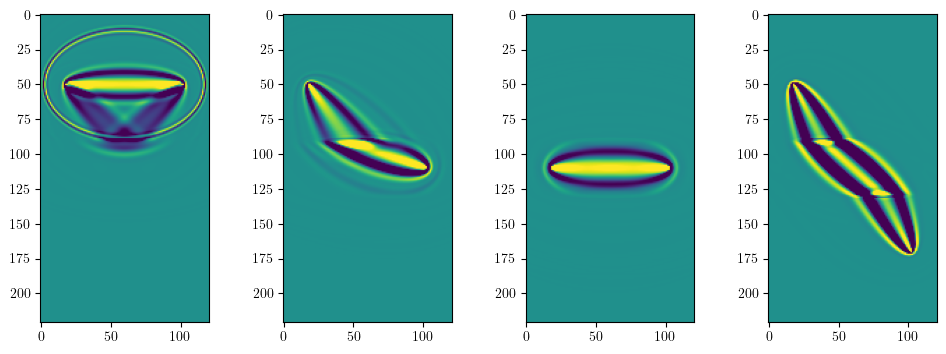

In [22]:
#NBVAL_IGNORE_OUTPUT
from devito import mmax
from examples.seismic import plot_image
qa = np.quantile(grad.numpy(), 0.999)

fig, axs = plt.subplots(1, 4, figsize=(12, 4))
for i, ax in enumerate(axs):
    qa = np.quantile(grad[i], 0.99)
    ax.imshow(grad[i].T, vmin=-qa, vmax=qa)

plt.show()

Having defined our FWI gradient procedure we can compute the initial iteration from our starting model. This allows us to visualize the gradient alongside the model perturbation and the effect of the gradient update on the model.

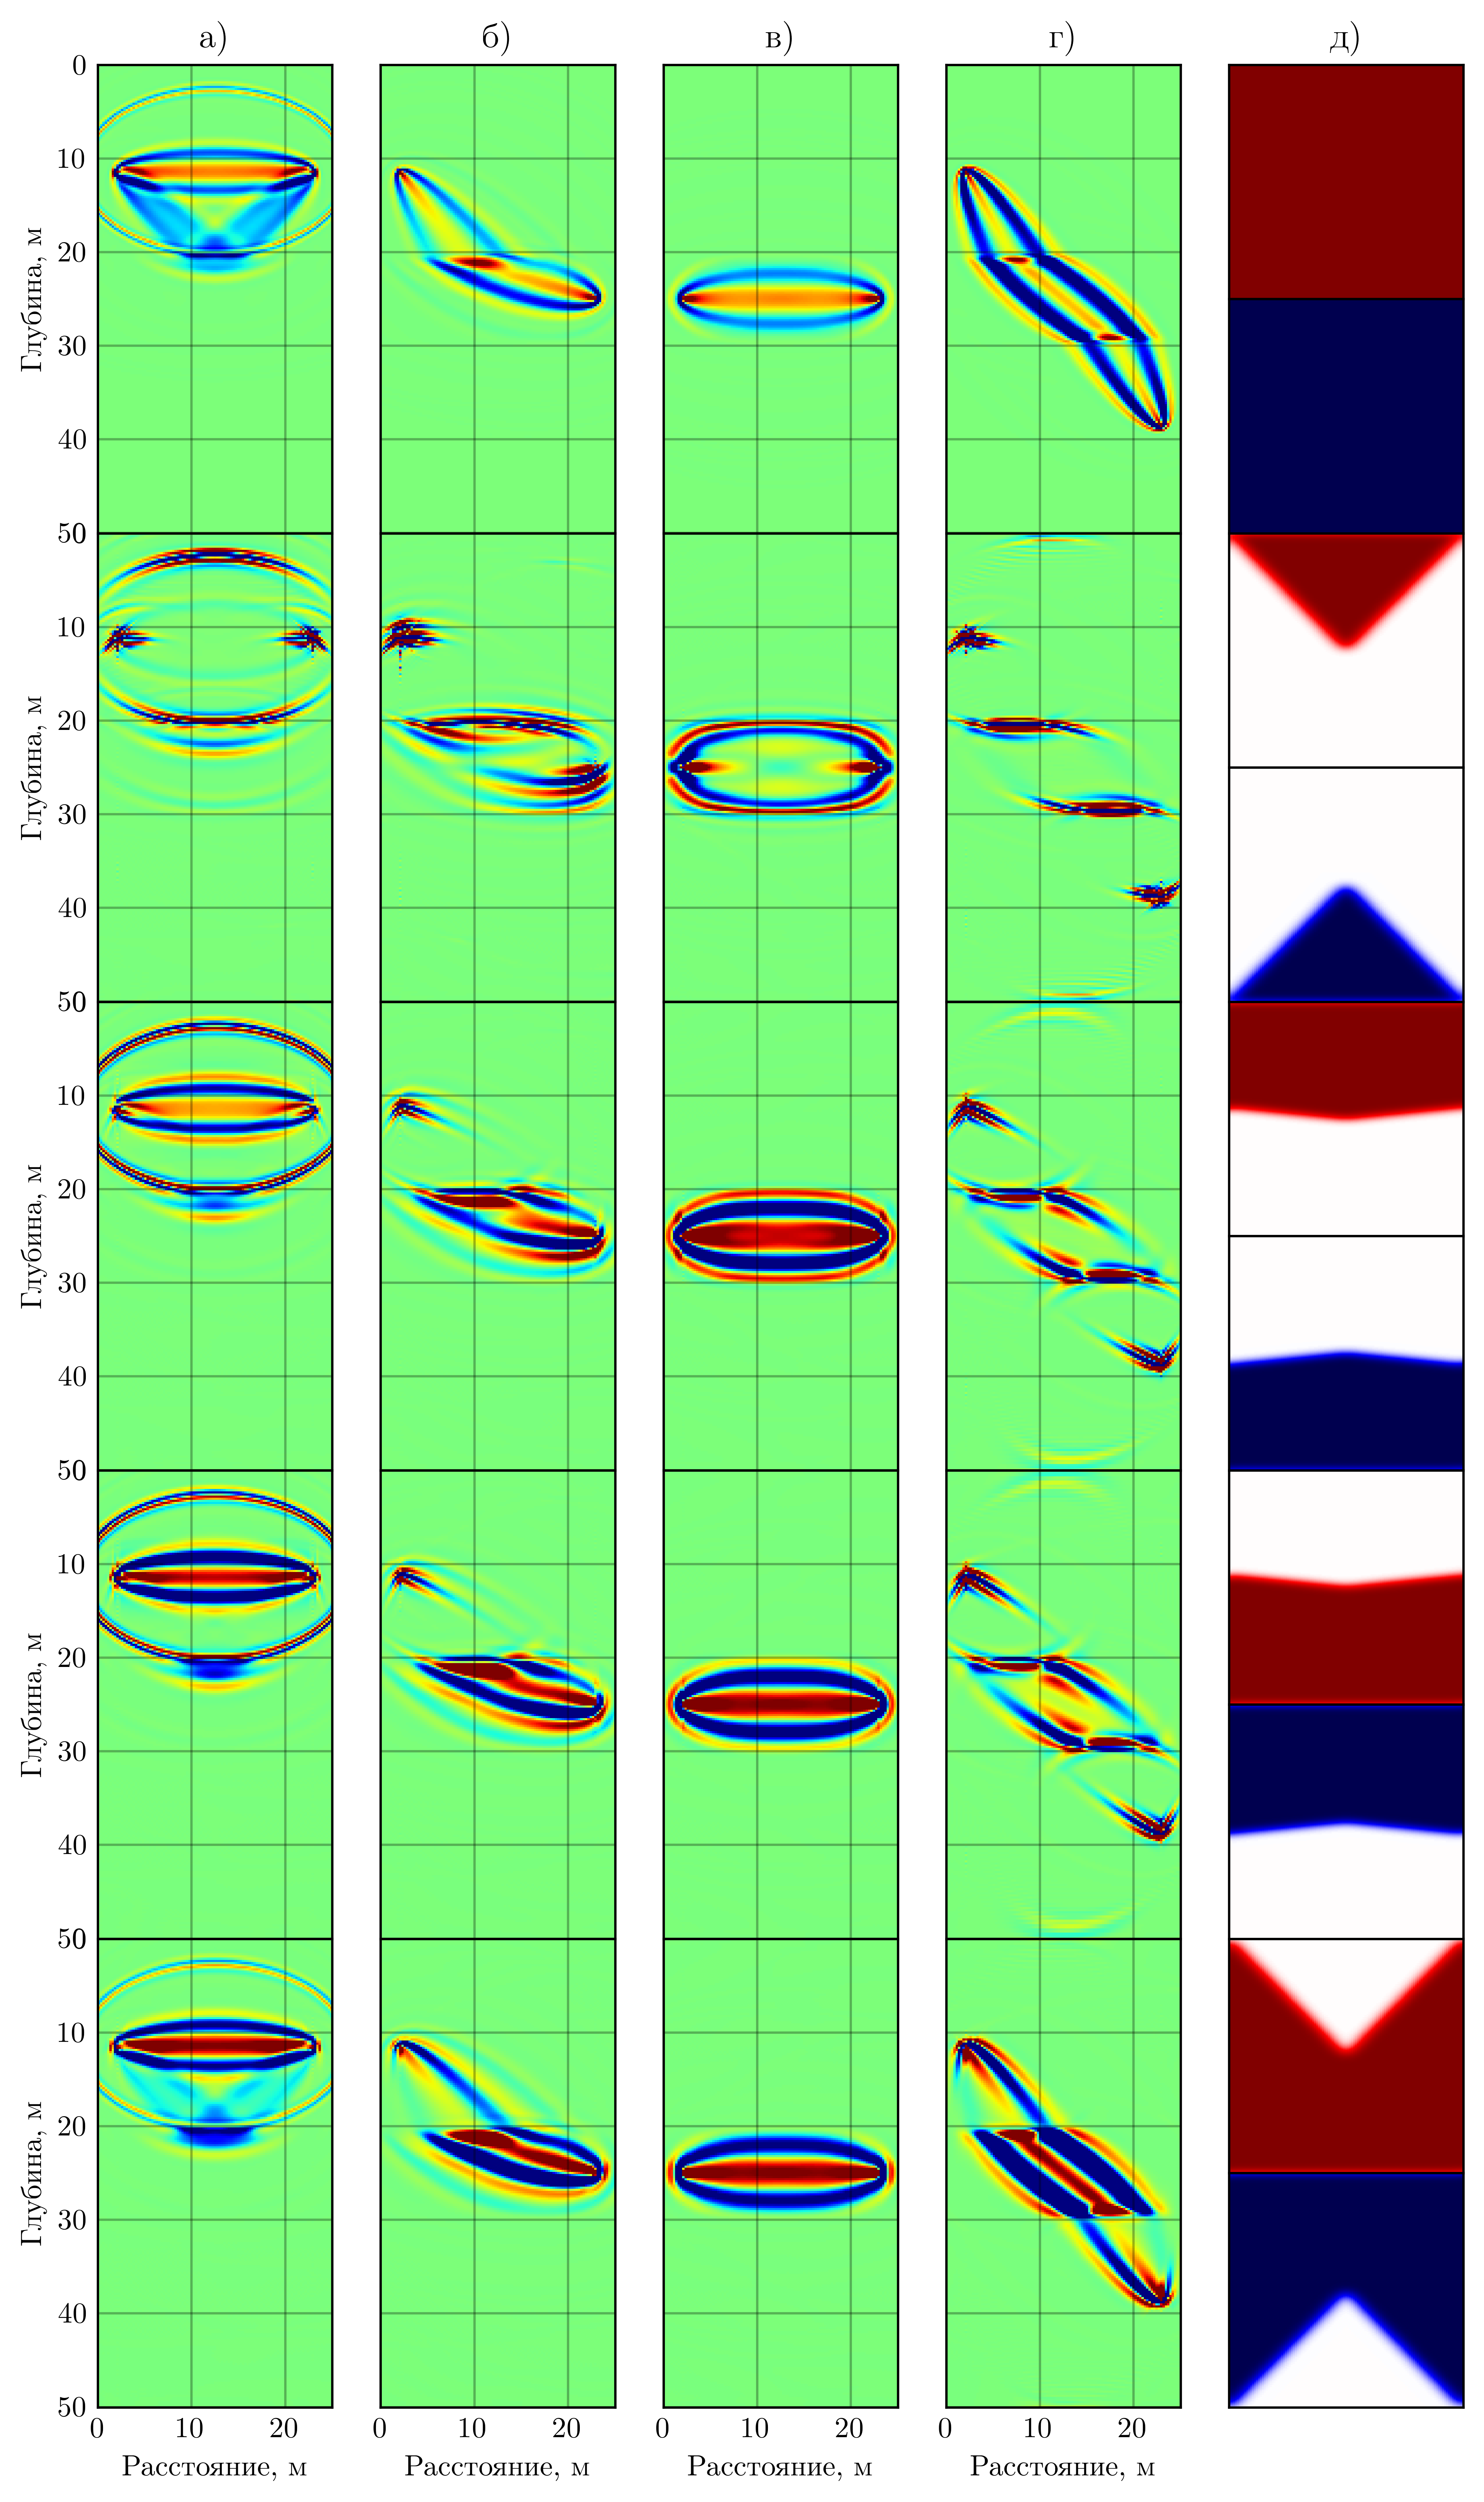

In [23]:
import matplotlib.gridspec as gridspec
from examples.seismic.fk_filter import FKFilter3D

extent = [0, (shape[0]+1)*spacing[0], (shape[1]+1)*spacing[1], 0]
nsnaps, sub_nx, sub_nz = u0_batch.shape[1:]

u0_batch = u0_batch.to('cuda')
v_batch = v_batch.to('cuda')
fkups = [] 
fkdowns = [] 
# Create figure with custom gridspec
fig = plt.figure(figsize=(7, 11.7), dpi=600)  # Wider figure to accommodate extra column
gs = gridspec.GridSpec(5, 5, figure=fig, wspace=0, hspace=0.00)  # 5 rows, 5 columns (4+1)

# Create main axes (first 4 columns)
axs_main = np.empty((5, 4), dtype=object)
for i in range(5):
    for j in range(4):
        axs_main[i, j] = fig.add_subplot(gs[i, j])

# Create right column with split subplots
axs_right = np.empty((5, 2), dtype=object)  # 5 rows, each with 2 subplots
for i in range(5):
    # Create a nested gridspec for each row in the right column
    right_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[i, 4], hspace=0.0)
    axs_right[i, 0] = fig.add_subplot(right_gs[0])
    axs_right[i, 1] = fig.add_subplot(right_gs[1])

for i, (min_sl, leaky) in enumerate(zip([1e-3, 1e-4, 1e-4, 1e-3], [-1, -1, 1, 1])):
    fk_down = FKFilter3D(
        dx=0.05,
        dz=0.05,
        dt=20/1000,
        sigma_x=0.2,
        sigma_z=0.2,
        min_slope=-min_sl,
        max_slope=leaky,
        gaussian_sigma=0,
        lower_min=0.0,
        upper_min=0.0,
        low_cut=0.1,
        high_cut=1.5,
        low_slope=6,
        high_slope=2,
        device="cuda",
    )

    fk_up = FKFilter3D(
        dx=0.05,
        dz=0.05,
        dt=20/1000,
        sigma_x=0.2,
        sigma_z=0.2,
        min_slope=min_sl,
        max_slope=leaky,
        gaussian_sigma=0,
        lower_min=0.0,
        upper_min=0.0,
        low_cut=0.0,
        high_cut=1.5,
        low_slope=6,
        high_slope=2,
        device="cuda",
    )

    fk_up._compute_filter(sub_nz, sub_nx, nsnaps)
    fk_down._compute_filter(sub_nz, sub_nx, nsnaps)
    if i == 0:
        fkups.append(fk_up.filter[..., 500].cpu().numpy()*0+1)
        fkdowns.append(fk_down.filter[..., 500].cpu().numpy()*0+1)
    fkups.append(fk_up.filter[..., 500].cpu().numpy())
    fkdowns.append(fk_down.filter[..., 500].cpu().numpy())

    u0_up = fk_up((u0_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
    u0_down = fk_down((u0_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
    v_up = fk_up((v_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
    v_down = fk_down((v_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)

    grad_up = calc_grad_batch(u0_up, v_down, dt=1)
    grad_down = calc_grad_batch(u0_down, v_up, dt=1)
    
    buff = grad_up+grad_down
    buff = buff.cpu().numpy()

    for j, ax in enumerate(axs_main[i+1, :]):
        qa = np.quantile(buff[j], 0.99)
        ax.imshow(buff[j][10:-10].T, vmin=-qa, vmax=qa, cmap='jet', extent=extent)
        ax.grid(True, linestyle='-', alpha=0.3, color='black')
        ax.tick_params(axis='both', which='both', length=0)  # Hide tick marks

# First row (common gradient)
grad_common = calc_grad_batch(u0_batch, v_batch, dt=1)
for j, ax in enumerate(axs_main[0, :]):
    qa = np.quantile(grad_common.cpu().numpy()[j], 0.999)
    ax.imshow(grad_common.cpu().numpy()[j][10:-10].T, vmin=-qa, vmax=qa, cmap='jet', extent=extent)
    ax.grid(True, linestyle='-', alpha=0.3, color='black')
    ax.tick_params(axis='both', which='both', length=0)  # Hide tick marks


upper_batch = np.array(fkdowns)
lower_batch = np.array(fkups)

# Add lower_batch and upper_batch to the right column
for i in range(5):
    # Upper subplot
    
    qa_upper = 1.01*np.max(upper_batch[i])
    axs_right[i, 0].imshow(upper_batch[i], vmin=-qa_upper, vmax=qa_upper, cmap='seismic', aspect=1, extent=[-10, 10, 10, -10])
    axs_right[i, 0].tick_params(axis='both', which='both', length=0)
    
    # Lower subplot
    qa_lower = 1.01*np.max(lower_batch[i])
    axs_right[i, 1].imshow(-lower_batch[i], vmin=-qa_upper, vmax=qa_lower, cmap='seismic', aspect=1, extent=[-10, 10, 10, -10])
    axs_right[i, 1].tick_params(axis='both', which='both', length=0)

# Remove inner labels and ticks
for ax in axs_main.flat:
    ax.set_xticks([0, 10, 20])
    # ax.set_yticks([0, ])

    ax.label_outer()
    
for ax in axs_right.flat:
    ax.set_xticklabels([])
    ax.set_yticklabels([])

#     ax.label_outer()
for ax in axs_main[-1, :]:
    ax.set_xlabel('Расстояние, м')
    
for ax in axs_main[:, 0]:
    ax.set_ylabel('Глубина, м')
    
titles = ["а", "б", "в", "г", "д"]
for ax, ti in zip(axs_main[0, :], titles):
    ax.set_title(ti+")")
axs_right.flat[0].set_title("д)")

# Make layout as tight as possible
plt.tight_layout(pad=0.0)
plt.savefig("../../../Wavepath/Pic Big0.png")
plt.show()

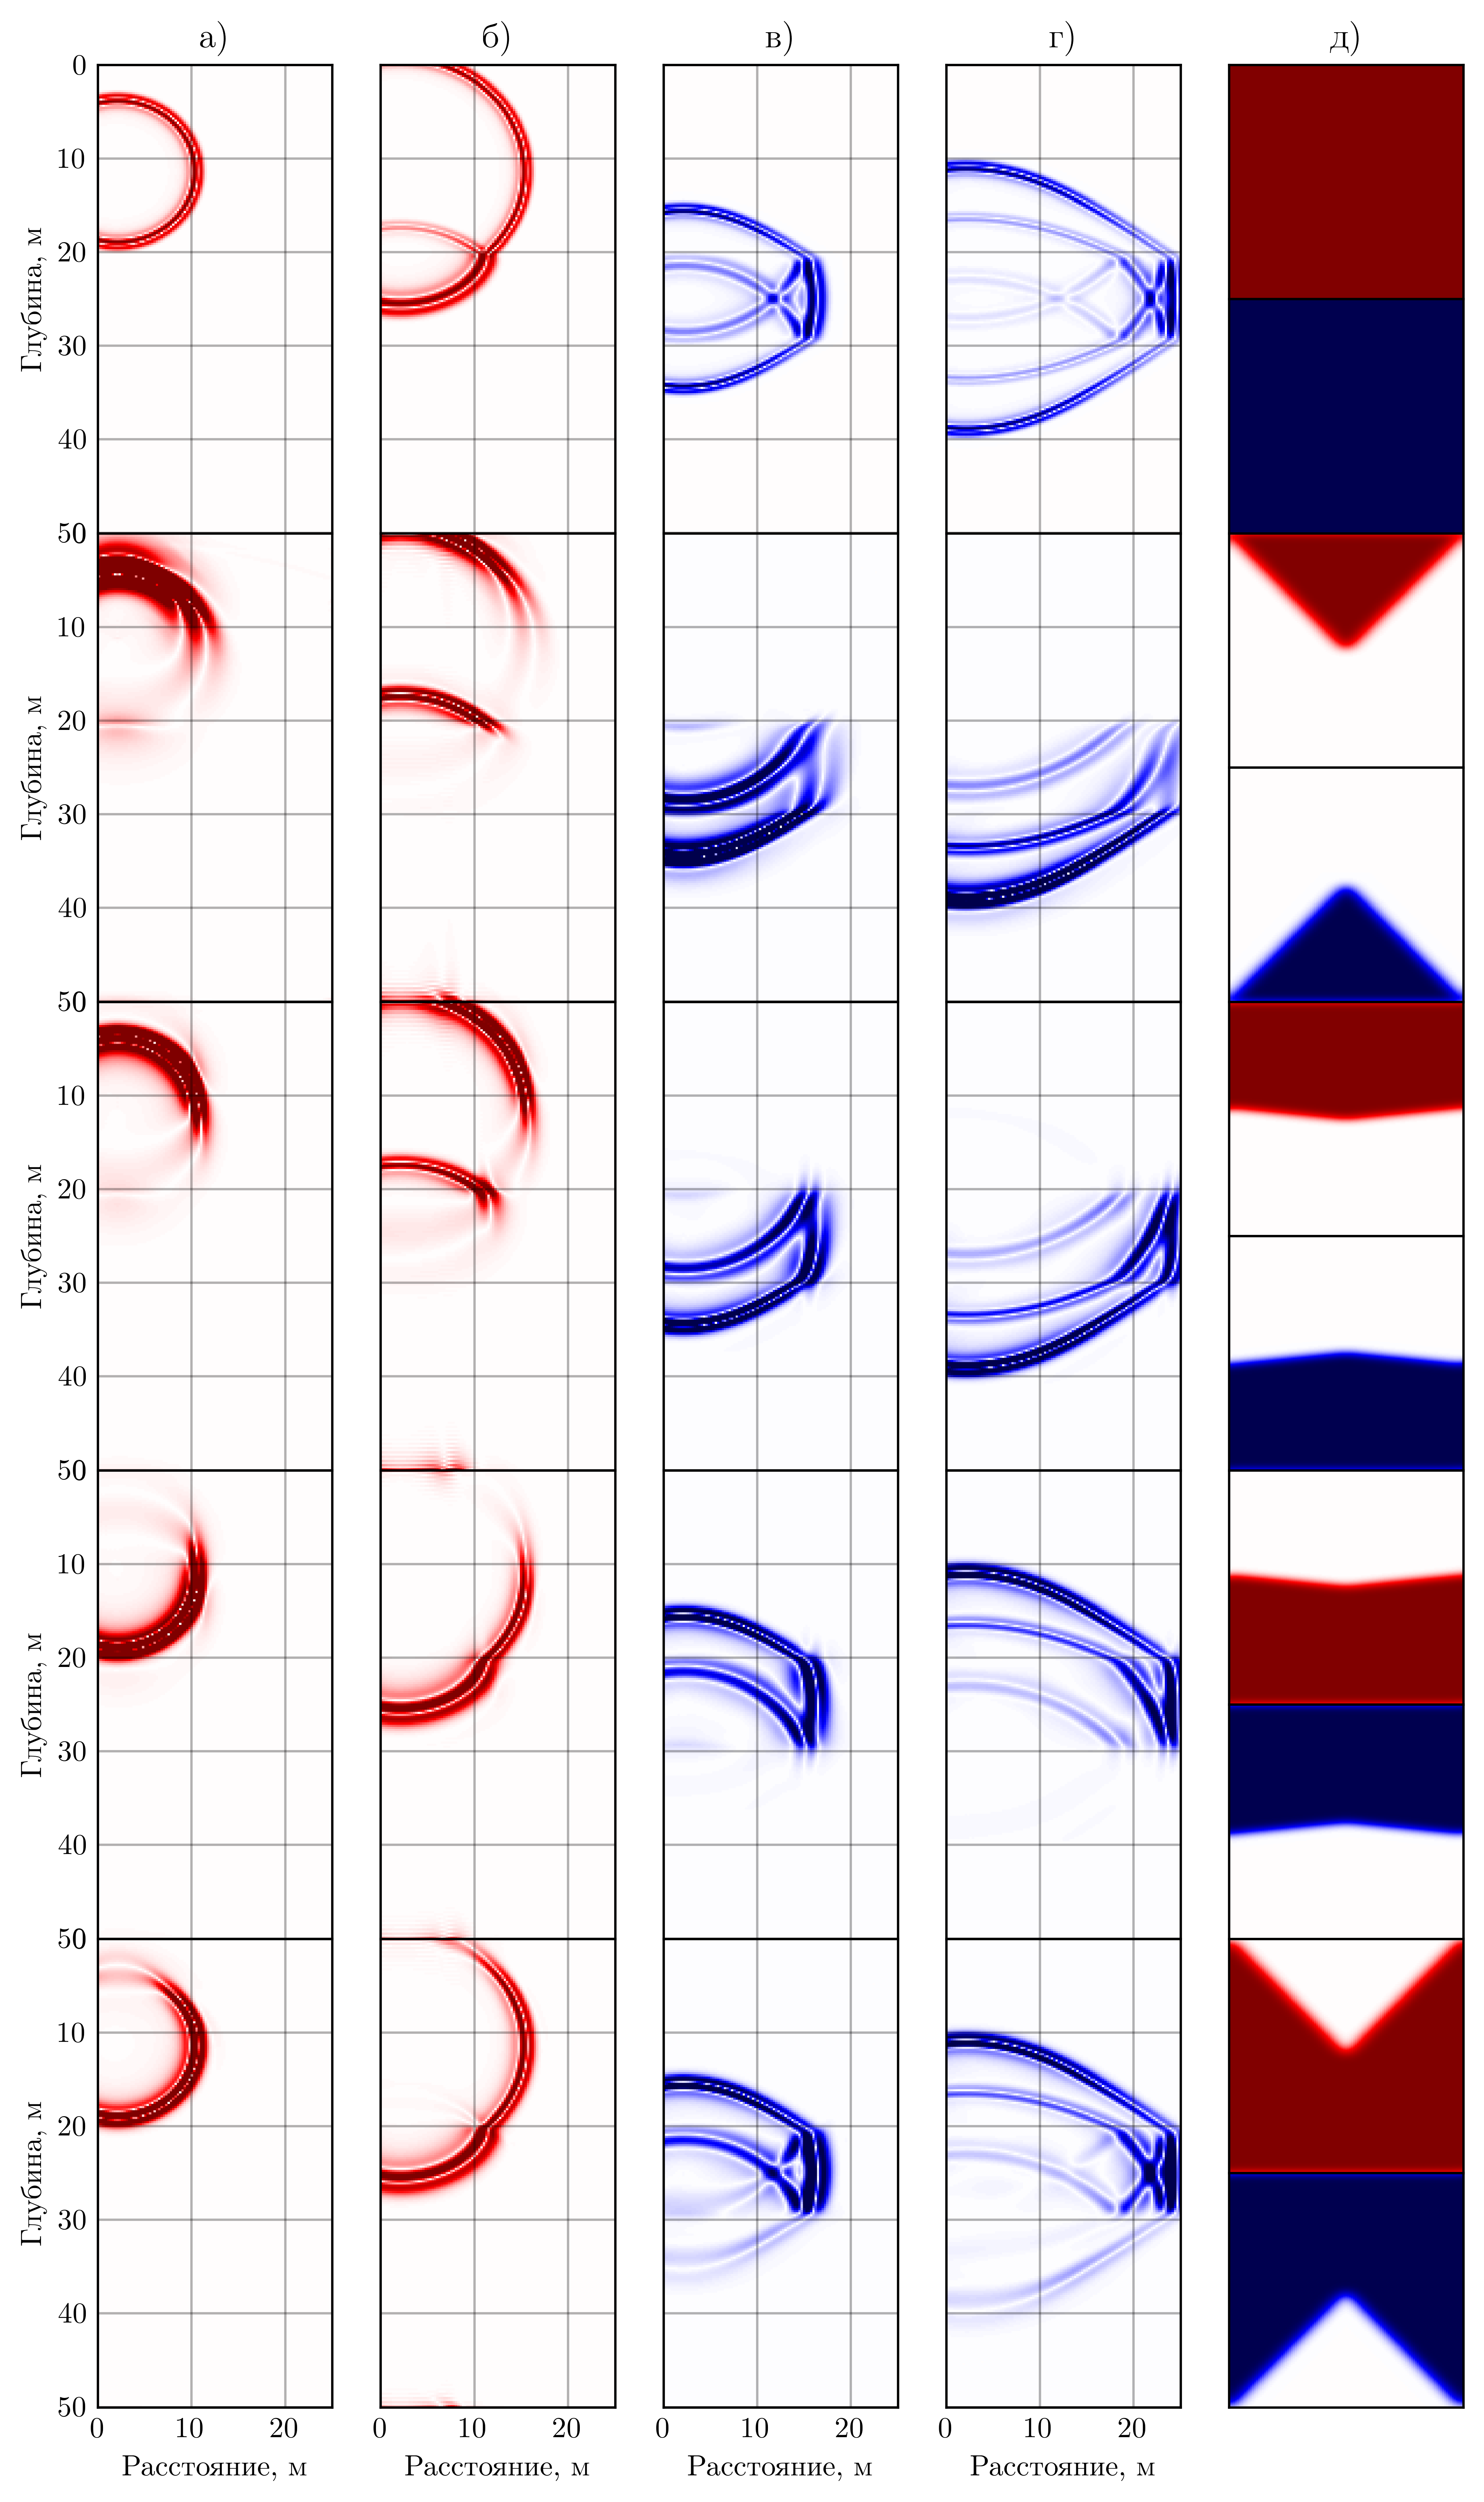

In [ ]:
import matplotlib.gridspec as gridspec
from examples.seismic.fk_filter import FKFilter3D

extent = [0, (shape[0]+1)*spacing[0], (shape[1]+1)*spacing[1], 0]
nsnaps, sub_nx, sub_nz = u0_batch.shape[1:]

u0_batch = u0_batch.to('cuda')
v_batch = v_batch.to('cuda')
fkups = [] 
fkdowns = [] 
# Create figure with custom gridspec
fig = plt.figure(figsize=(7, 11.7), dpi=600)  # Wider figure to accommodate extra column
gs = gridspec.GridSpec(5, 5, figure=fig, wspace=0, hspace=0.00)  # 5 rows, 5 columns (4+1)

# Create main axes (first 4 columns)
axs_main = np.empty((5, 4), dtype=object)
for i in range(5):
    for j in range(4):
        axs_main[i, j] = fig.add_subplot(gs[i, j])

# Create right column with split subplots
axs_right = np.empty((5, 2), dtype=object)  # 5 rows, each with 2 subplots
for i in range(5):
    # Create a nested gridspec for each row in the right column
    right_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[i, 4], hspace=0.0)
    axs_right[i, 0] = fig.add_subplot(right_gs[0])
    axs_right[i, 1] = fig.add_subplot(right_gs[1])

for i, (min_sl, leaky) in enumerate(zip([1e-3, 1e-4, 1e-4, 1e-3], [-1, -1, 1, 1])):
    fk_down = FKFilter3D(
        dx=0.05,
        dz=0.05,
        dt=20/1000,
        sigma_x=0.2,
        sigma_z=0.2,
        min_slope=-min_sl,
        max_slope=leaky,
        gaussian_sigma=0,
        lower_min=0.0,
        upper_min=0.0,
        low_cut=0.1,
        high_cut=1.5,
        low_slope=6,
        high_slope=2,
        device="cuda",
    )

    fk_up = FKFilter3D(
        dx=0.05,
        dz=0.05,
        dt=20/1000,
        sigma_x=0.2,
        sigma_z=0.2,
        min_slope=min_sl,
        max_slope=leaky,
        gaussian_sigma=0,
        lower_min=0.0,
        upper_min=0.0,
        low_cut=0.0,
        high_cut=1.5,
        low_slope=6,
        high_slope=2,
        device="cuda",
    )

    fk_up._compute_filter(sub_nz, sub_nx, nsnaps)
    fk_down._compute_filter(sub_nz, sub_nx, nsnaps)
    if i == 0:
        fkups.append(fk_up.filter[..., 500].cpu().numpy()*0+1)
        fkdowns.append(fk_down.filter[..., 500].cpu().numpy()*0+1)
    fkups.append(fk_up.filter[..., 500].cpu().numpy())
    fkdowns.append(fk_down.filter[..., 500].cpu().numpy())

    u0_up = fk_up((u0_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
    u0_down = fk_down((u0_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
    v_up = fk_up((v_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
    v_down = fk_down((v_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)

    grad_up = calc_grad_batch(u0_up, v_down, dt=1)
    grad_down = calc_grad_batch(u0_down, v_up, dt=1)
    
    u0_up = u0_up.cpu().numpy()
    u0_down = u0_down.cpu().numpy()
    
    buff = [u0_up[0][200], u0_up[0][300], u0_down[2][200], u0_down[2][300]]
    # buff = buff.cpu().numpy()

    for j, (ax, sign) in enumerate(zip(axs_main[i+1, :], [1, 1, -1, -1])):
        qa = np.quantile(buff[j], 0.99)
        ax.imshow(sign*np.abs(buff[j][10:-10].T), vmin=-qa, vmax=qa, cmap='seismic', extent=extent)
        ax.grid(True, linestyle='-', alpha=0.3, color='black')
        ax.tick_params(axis='both', which='both', length=0)  # Hide tick marks


u0_batch_b = u0_batch.cpu().numpy()
buff = [u0_batch_b[0][200], u0_batch_b[0][300], u0_batch_b[2][200], u0_batch_b[2][300]]
for j, (ax, tidx, bu, sign) in enumerate(zip(axs_main[0, :],[200, 300, 200, 300], buff, [1, 1, -1, -1])):
    qa = np.quantile(bu, 0.999)
    ax.imshow(sign*np.abs(bu[10:-10].T), vmin=-qa, vmax=qa, cmap='seismic', extent=extent)
    ax.grid(True, linestyle='-', alpha=0.3, color='black')
    ax.tick_params(axis='both', which='both', length=0)  # Hide tick marks


upper_batch = np.array(fkdowns)
lower_batch = np.array(fkups)

# Add lower_batch and upper_batch to the right column
for i in range(5):
    # Upper subplot
    
    qa_upper = 1.01*np.max(upper_batch[i])
    axs_right[i, 0].imshow(upper_batch[i], vmin=-qa_upper, vmax=qa_upper, cmap='seismic', aspect=1, extent=[-10, 10, 10, -10])
    axs_right[i, 0].tick_params(axis='both', which='both', length=0)
    
    # Lower subplot
    qa_lower = 1.01*np.max(lower_batch[i])
    axs_right[i, 1].imshow(-lower_batch[i], vmin=-qa_upper, vmax=qa_lower, cmap='seismic', aspect=1, extent=[-10, 10, 10, -10])
    axs_right[i, 1].tick_params(axis='both', which='both', length=0)

# Remove inner labels and ticks
for ax in axs_main.flat:
    ax.set_xticks([0, 10, 20])
    # ax.set_yticks([0, ])

    ax.label_outer()
    
for ax in axs_right.flat:
    ax.set_xticklabels([])
    ax.set_yticklabels([])

#     ax.label_outer()
for ax in axs_main[-1, :]:
    ax.set_xlabel('Расстояние, м')

titles = ["а", "б", "в", "г", "д"]
for ax, ti in zip(axs_main[0, :], titles):
    ax.set_title(ti+")")
axs_right.flat[0].set_title("д)")

for ax in axs_main[:, 0]:
    ax.set_ylabel('Глубина, м')

# Make layout as tight as possible
plt.tight_layout(pad=0.0)
plt.savefig("../../../Wavepath/Pic Big1.png")
plt.show()

In [25]:

# nsnaps, sub_nx, sub_nz = (1000, 1000, 1000)




In [26]:
u0_batch = u0_batch.to('cuda')
v_batch = v_batch.to('cuda')

u0_up = fk_up((u0_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
u0_down = fk_down((u0_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
v_up = fk_up((v_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)
v_down = fk_down((v_batch).permute(0, 3, 2, 1)).permute(0, 3, 2, 1)

grad_up = calc_grad_batch(u0_up, v_down, dt=1)
grad_down = calc_grad_batch(u0_down, v_up, dt=1)
grad_common = calc_grad_batch(u0_batch, v_batch, dt=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.877002e-13..2.1820052e-12].


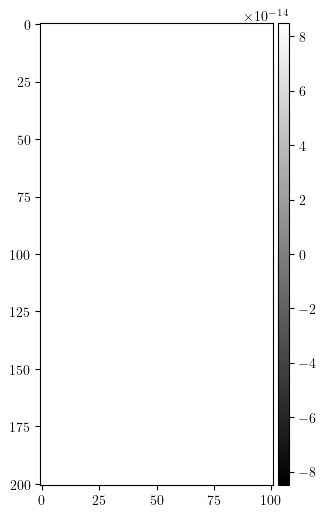

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5403293e-13..4.4357378e-13].


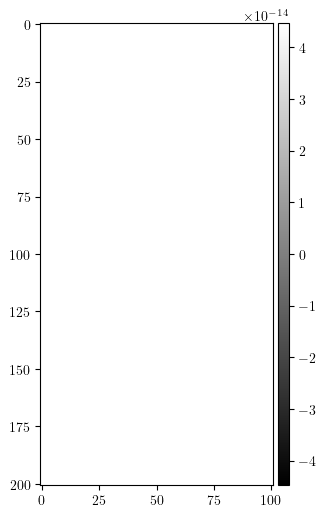

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.560521e-13..4.570265e-13].


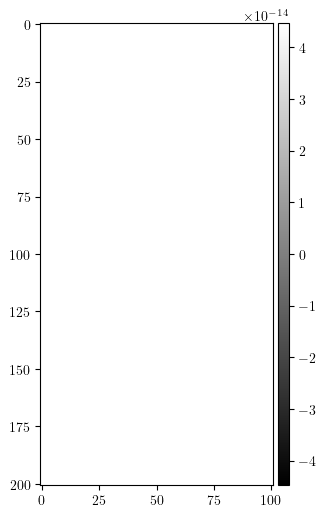

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4613195e-13..9.006003e-13].


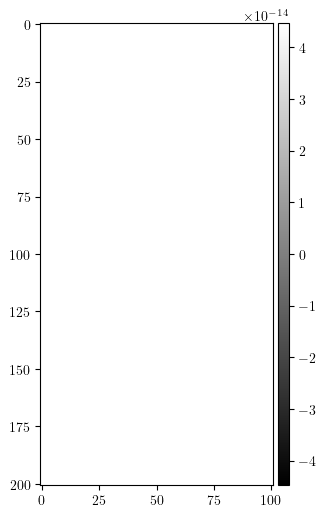

In [27]:
#NBVAL_IGNORE_OUTPUT
from devito import mmax
from examples.seismic import plot_image
qa = np.quantile(grad.numpy(), 0.99)

# Plot the FWI gradient
plot_image(grad.numpy()[:, 10:-10, 10:-10],
           vmin=-qa, vmax=qa,
           cmap="gray")
qa = np.quantile(grad_up.cpu().numpy(), 0.999)
plot_image(grad_up.cpu().numpy()[:, 10:-10, 10:-10],
           vmin=-qa, vmax=qa,
           cmap="gray")
plot_image(grad_down.cpu().numpy()[:, 10:-10, 10:-10],
           vmin=-qa, vmax=qa,
           cmap="gray")
plot_image((grad_up.cpu().numpy() + grad_down.cpu().numpy())[:, 10:-10, 10:-10],
           vmin=-qa, vmax=qa,
           cmap="gray")

In [ ]:
#NBVAL_IGNORE_OUTPUT
from devito import mmax
from examples.seismic import plot_image
qa = np.quantile(grad_full_c.cpu().numpy(), 0.9999)

# Plot the FWI gradient
plot_image(grad_full_c.cpu().numpy(),
           vmin=-qa, vmax=qa,
           cmap="jet")

qa = np.quantile(grad_full_u.cpu().numpy(), 0.9999)

plot_image(grad_full_u.cpu().numpy(),
           vmin=-qa, vmax=qa,
           cmap="jet")

qa = np.quantile(grad_full_d.cpu().numpy(), 0.9999)
plot_image(grad_full_d.cpu().numpy(),
           vmin=-qa, vmax=qa,
           cmap="jet")

grad_fin = grad_full_u.cpu().numpy() + grad_full_d.cpu().numpy()
grad_fin /= np.max(grad_fin)

grad_fin_c = grad_full_c.cpu().numpy()
grad_fin_c /= np.max(grad_fin_c)

qa = np.quantile(grad_fin, 0.9999)
plot_image(-grad_fin,
           vmin=-1, vmax=1,
           cmap="jet")

update = -0.5 * grad_fin / np.quantile(grad_fin, 0.9999)
update_c = -0.5 * grad_fin_c / np.quantile(grad_fin_c, 0.9999)


# # Plot the difference between the true and initial model.
# # This is not known in practice as only the initial model is provided.
# plot_image(model0.vp.data[model.nbl:-model.nbl, model.nbl:-model.nbl] - model.vp.data[model.nbl:-model.nbl, model.nbl:-model.nbl], vmin=-5e-1, vmax=5e-1, cmap="jet")
buff = model0.vp.data[model.nbl:-model.nbl+1, model.nbl:-model.nbl+1][::5, ::5]
plot_image(buff + update, vmin=1.5, vmax=3.5, cmap="jet")
# plot_image(model0.vp.data[model.nbl:-model.nbl, model.nbl:-model.nbl] ,vmin=1.5, vmax=3.5, cmap="jet")
# plot_image(model.vp.data[model.nbl:-model.nbl, model.nbl:-model.nbl] ,vmin=1.5, vmax=3.5, cmap="jet")


NameError: name 'grad_full_c' is not defined

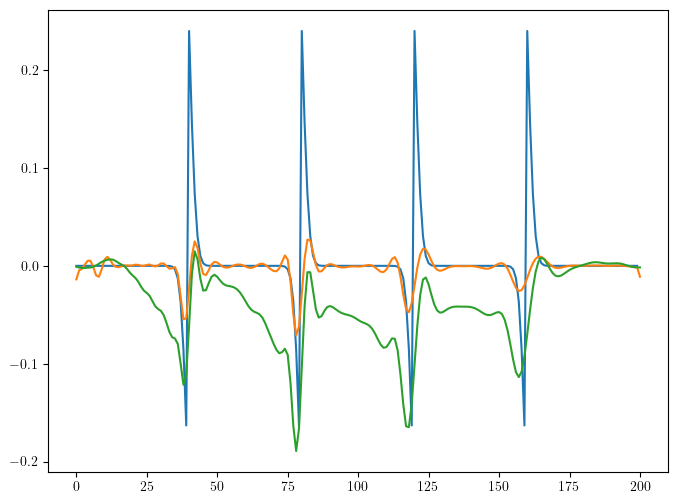

In [ ]:
true_perturb = model.vp.data[model.nbl:-model.nbl, model.nbl:-model.nbl] - model0.vp.data[model.nbl:-model.nbl, model.nbl:-model.nbl]
true_perturb = true_perturb[::5, ::5]
plt.plot(true_perturb[buff.shape[0]//2, :])
plt.plot(update[buff.shape[0]//2, :])
plt.plot(update_c[buff.shape[0]//2, :])

plt.show()

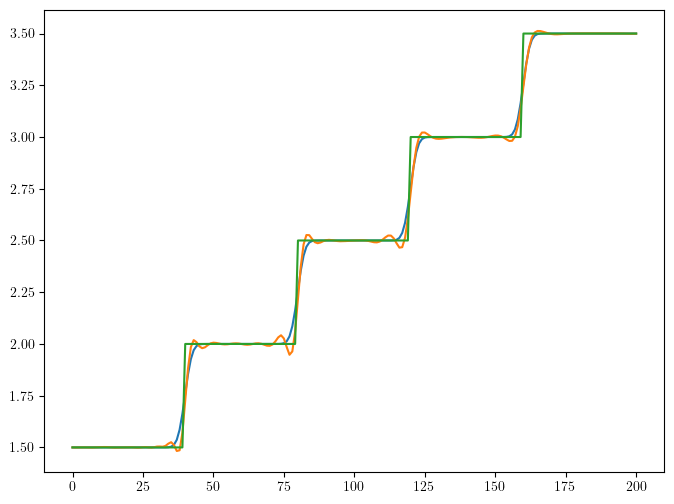

In [ ]:
plt.plot(buff[buff.shape[0]//2, :])
plt.plot((buff+update)[buff.shape[0]//2, :])
plt.plot((buff-update_c/5)[buff.shape[0]//2, :])

truemod = model.vp.data[model.nbl:-model.nbl+1, model.nbl:-model.nbl+1][::5, ::5]
plt.plot(truemod[buff.shape[0]//2, :])
plt.show()

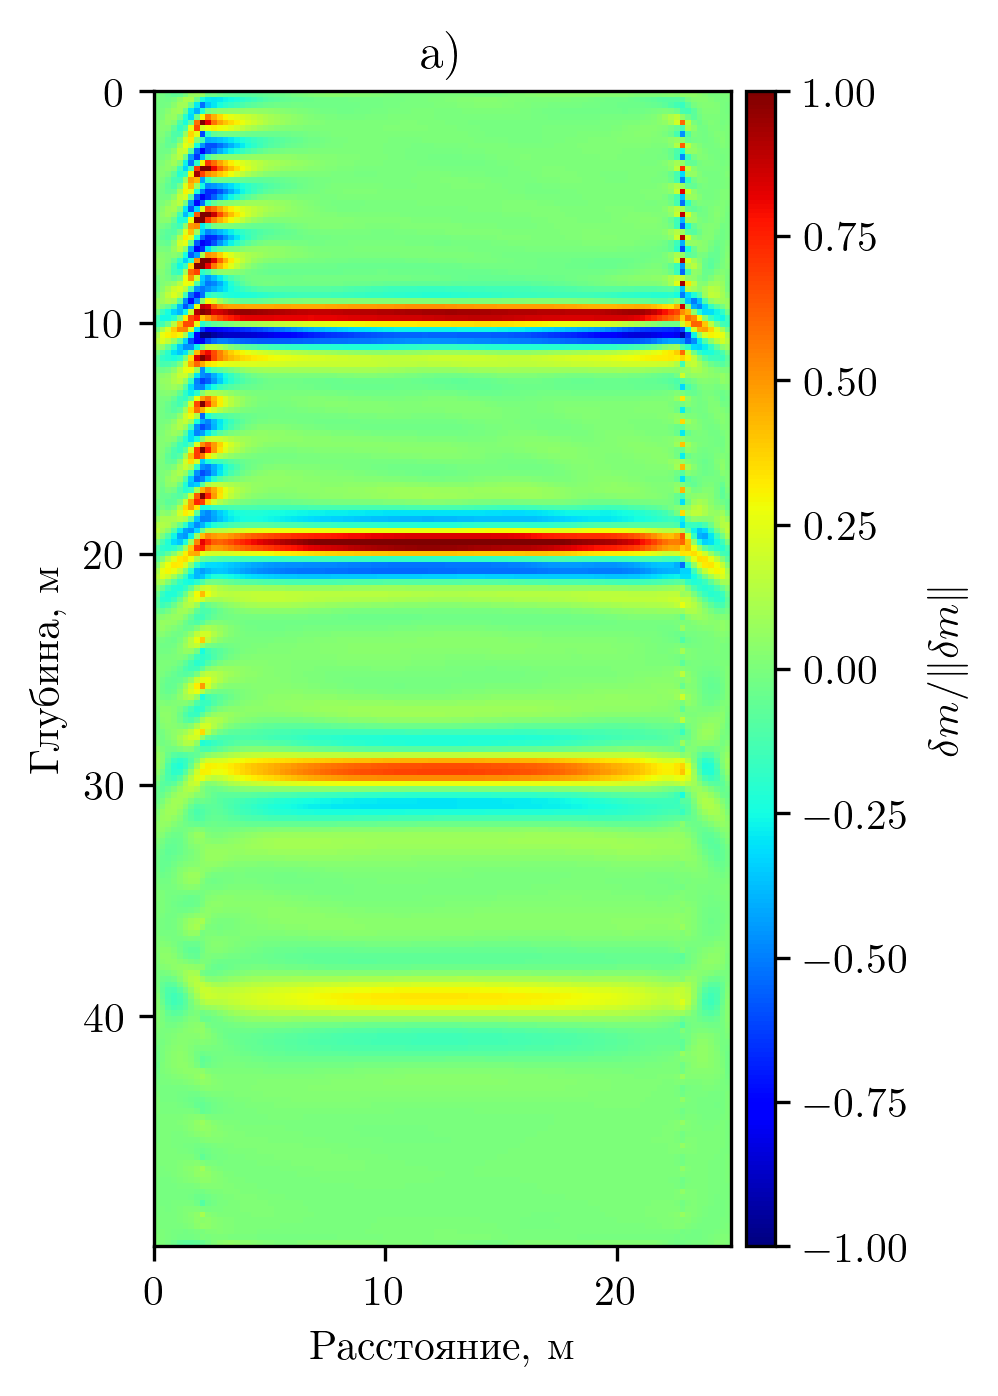

In [ ]:
fig, axs = plt.subplots(1, 1, dpi=300, figsize=(4, 5))
domain_size = 1.0 * np.array(model.domain_size)
extent = [
    model.origin[0],
    model.origin[0] + domain_size[0],
    model.origin[1] + domain_size[1],
    model.origin[1],
]

plot = axs.imshow(-grad_fin.T,
           vmin=-1, vmax=1,
           cmap="jet",
            extent=extent,
            )
axs.set_xlabel("Расстояние, м")
axs.set_ylabel("Глубина, м")
axs.set_title("а)")
divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(plot, cax=cax)
cbar.set_label(r"${\delta m} / {\| \delta m \|}$")
plt.savefig("../../../Normalization part pics/Pic 2_1.png")
plt.show()

We see that the gradient and the true perturbation have the same sign, therefore, with an appropriate scaling factor, we will update the model in the correct direction.

In [ ]:
from devito import Min, Max
# Define bounding box constraints on the solution.
def update_with_box(vp, alpha, dm, vmin=2.0, vmax=3.5):
    """
    Apply gradient update in-place to vp with box constraint

    Notes:
    ------
    For more advanced algorithm, one will need to gather the non-distributed
    velocity array to apply constrains and such.
    """
    update = vp + alpha * dm
    update_eq = Eq(vp, Max(Min(update, vmax), vmin))
    Operator(update_eq)()

In [ ]:
#NBVAL_SKIP

from devito import mmax

# Run FWI with gradient descent
history = np.zeros((fwi_iterations, 1))
for i in range(0, fwi_iterations):
    # Compute the functional value and gradient for the current
    # model estimate
    phi, direction = fwi_gradient(model0.vp)
    
    # Store the history of the functional values
    history[i] = phi
    
    # Artificial Step length for gradient descent
    # In practice this would be replaced by a Linesearch (Wolfe, ...)
    # that would guarantee functional decrease Phi(m-alpha g) <= epsilon Phi(m)
    # where epsilon is a minimum decrease constant
    alpha = .05 / mmax(direction)
    
    # Update the model estimate and enforce minimum/maximum values
    update_with_box(model0.vp , alpha , direction)
    
    # Log the progress made
    print('Objective value is %f at iteration %d' % (phi, i+1))

Objective value is 39292.605833 at iteration 1
Objective value is 24506.628229 at iteration 2
Objective value is 14386.573665 at iteration 3
Objective value is 7907.616850 at iteration 4
Objective value is 3960.106497 at iteration 5


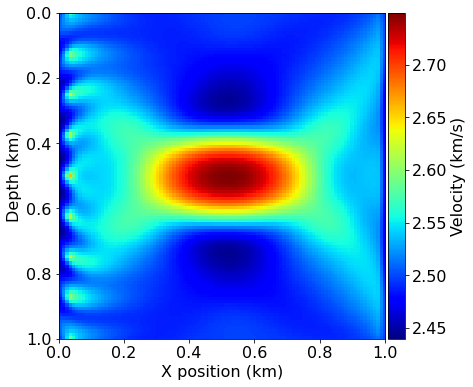

In [ ]:
#NBVAL_IGNORE_OUTPUT

# Plot inverted velocity model
plot_velocity(model0)

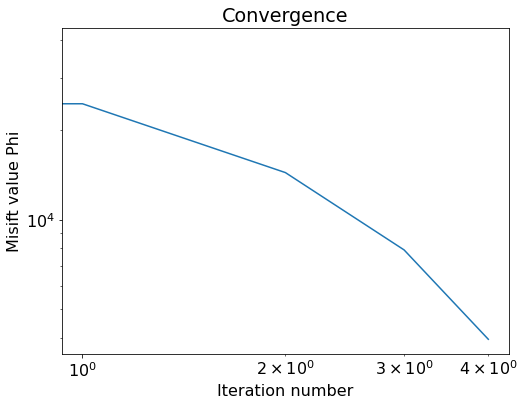

In [ ]:
#NBVAL_SKIP
import matplotlib.pyplot as plt

# Plot objective function decrease
plt.figure()
plt.loglog(history)
plt.xlabel('Iteration number')
plt.ylabel('Misift value Phi')
plt.title('Convergence')
plt.show()

## References

[1] _Virieux, J. and Operto, S.: An overview of full-waveform inversion in exploration geophysics, GEOPHYSICS, 74, WCC1–WCC26, doi:10.1190/1.3238367, http://library.seg.org/doi/abs/10.1190/1.3238367, 2009._

[2] _Haber, E., Chung, M., and Herrmann, F. J.: An effective method for parameter estimation with PDE constraints with multiple right hand sides, SIAM Journal on Optimization, 22, http://dx.doi.org/10.1137/11081126X, 2012._

<sup>This notebook is part of the tutorial "Optimised Symbolic Finite Difference Computation with Devito" presented at the Intel® HPC Developer Conference 2017.</sup>